In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import argparse

Considerando un potenziale armonico simmetrico $V_3(x) = kx^6$, se un corpo cade da una posizione $x=x_0$, per la conservazione dell'energia meccanica si ha:
$$ V(x_0)= \frac{1}{2} m v_x^2 + V(x) \rightarrow V(x_0)= \frac{1}{2} m \left( \frac{dx}{dt} \right)^2 + V(x) $$
Rimaneggiando l'uguaglianza di sopra si ottiene:
$$ dt = \sqrt{\frac{m}{2}} \frac{dx}{\sqrt{V(x_0) - V(x)}}$$
Siccome il potenziale è simmetrico rispetto all'origine, il periodo di oscillazione è dato da:
$$ T = 4 \int_{t(0)}^{t(x_0)} dt \Rightarrow T = \sqrt{8m} \int_0^{x_0} \frac{dx}{\sqrt{V(x_0) - V(x)}} $$

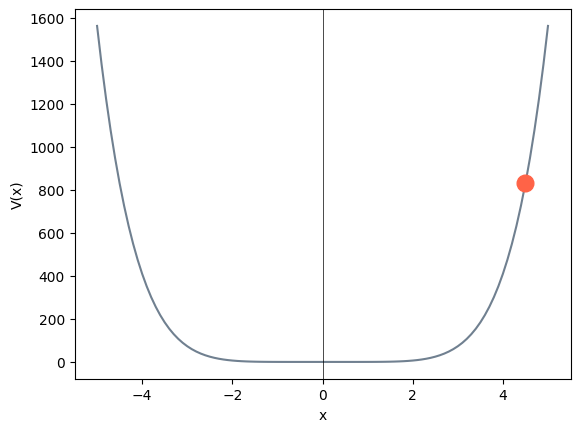

In [2]:
xx = np.arange(-5,5.05, 0.1)
plt.plot(xx, 0.1*xx**6, color='slategray')
plt.axvline(color='k', linewidth=0.5)
plt.xlabel('x')
plt.ylabel(r'V(x)')
plt.plot(4.5, 0.1*4.5**6, 'o', markersize=12, color='tomato')
plt.show()        

Si produca uno script python che calcoli il periodo di oscillazione in funzione del punto di partenza $x_0$ e produca il grafico di $T$ in funzione di $x$ ;
Ripetere l'analisi per diversi potenziali aventi simmetria rispetto all'origine:
$$ V_1(x) = kx^2 \quad \text{,} \quad V_2(x) = kx^4 \quad \text{,} \quad V_4(x)=k|x|^{3/2} $$

Utilizzare il modulo *argparse* per consentire la gestione dello scipt da terminale permettendo di scegliere le opzioni sul potenziale da visualizzare

In [10]:
# Setting del Poteniale

k=2
mass=2 #Kg
dx=0.1

def set_V(m,c):
    control=True
    while(control):
        m=input('massa: ')
        try: 
            float(m)
            control=False
        except: print('valore non valido. Riprova. \n')
    m=float(m)
    control=True
    while(control):
        c=input('costante di potenziale:')
        try:
            float(c)
            control=False
        except: print('valore non valido. Riprova \n')
    c=float(c)
    return m,c
    

mass, k=set_V(mass,k)
print('massa:',mass,' \t costante di potenziale:',k)

#Potenziali
def V1(x,k):
    return k*x**2
def V2(x,k):
    return k*x**4
def V3(x,k):
    return k*x**6 
def V4(x,k):
    return k*abs(x)**(3/2)

#Periodo al variare della posizione iniziale per ogni potenziale
def T(V,m,x_val):
    y=np.empty(0) 
    s=np.empty(0) 
    t1= np.sqrt(8*m)
    arr1= np.array([x for x in x_val if x>=0])
    for j in arr1:
        arr2=np.arange(0,j,dx) #intervallo di integrazione
        #print(arr2)
        for l in arr2:
            t2=(np.sqrt(V(j,k)-V(l,k)))**(-1)
            #print(t2)
            y= np.append(y,t2)
        t3=integrate.simpson(y,arr2)
        y=np.empty(0)
        t4=t1*t3
        s=np.append(s,t4)
    return s
#T(V1,mass,xx)

massa: 2.0  	 costante di potenziale: 0.3


Text(0.5, 1.0, '$v_4(x)=k|x|^{3/2}$')

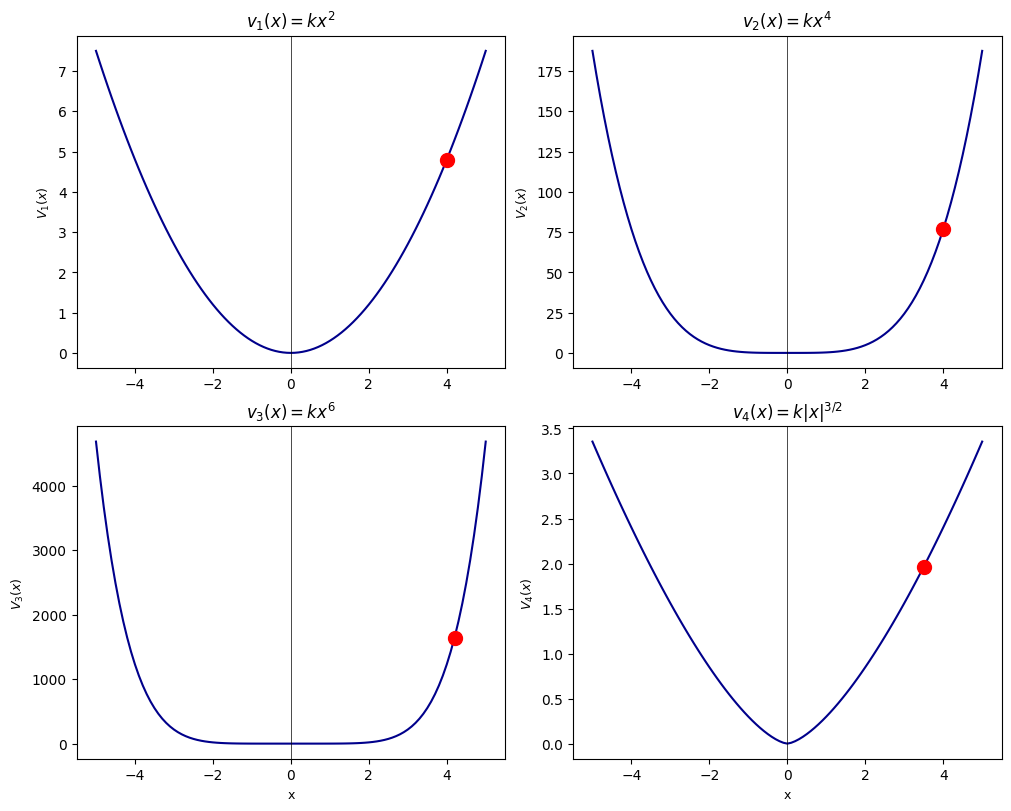

In [11]:
# Grafico dei potenziali
fig, (ax1,ax2) = plt.subplots(2,2, figsize=(10,8), layout='constrained')
ax1[0].plot(xx, V1(xx,k), color='darkblue')
ax1[0].axvline(color='k', linewidth=0.5)
ax1[0].plot(4., V1(4.,k), 'o', markersize=10, color='r')
ax1[0].set_ylabel(r'$V_1(x)$', fontsize=9)
ax1[0].set_title(r"$v_1(x)=kx^2$", fontsize=12)

ax2[0].plot(xx, V3(xx,k), color='darkblue')
ax2[0].axvline(color='k', linewidth=0.5)
ax2[0].plot(4.2, V3(4.2,k), 'o', markersize=10, color='r')
ax2[0].set_xlabel('x', fontsize=9)
ax2[0].set_ylabel(r'$V_3(x)$', fontsize=9)
ax2[0].set_title(r"$v_3(x)=kx^6$", fontsize=12)

ax1[1].plot(xx, V2(xx,k), color='darkblue')
ax1[1].axvline(color='k', linewidth=0.5)
ax1[1].plot(4., V2(4.,k), 'o', markersize=10, color='r')
ax1[1].set_ylabel(r'$V_2(x)$', fontsize=9)
ax1[1].set_title(r"$v_2(x)=kx^4$", fontsize=12)

ax2[1].plot(xx, V4(xx,k), color='darkblue')
ax2[1].axvline(color='k', linewidth=0.5)
ax2[1].plot(3.5, V4(3.5,k), 'o', markersize=10, color='r')
ax2[1].set_xlabel('x', fontsize=9)
ax2[1].set_ylabel(r'$V_4(x)$', fontsize=9)
ax2[1].set_title(r"$v_4(x)=k|x|^{3/2}$", fontsize=12)

Text(0.5, 1.0, '$v_4(x)=k|x|^{3/2}$')

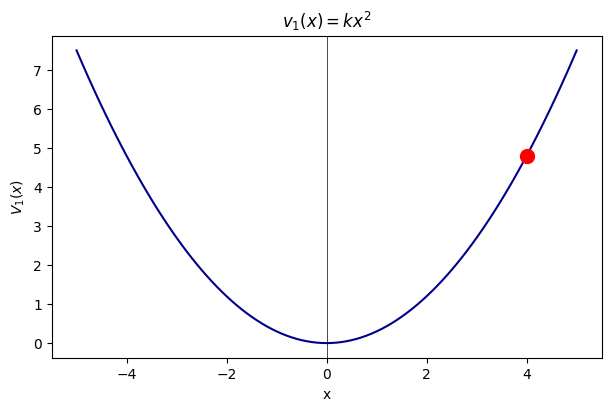

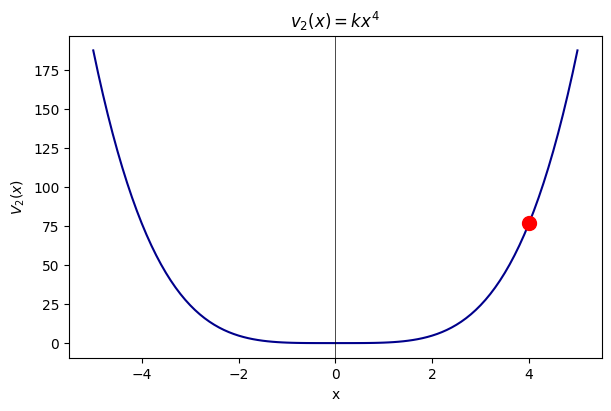

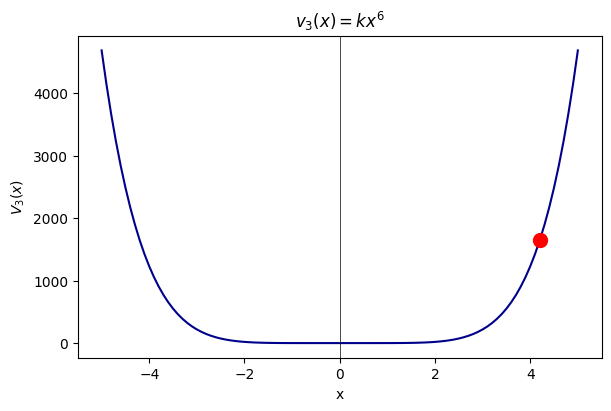

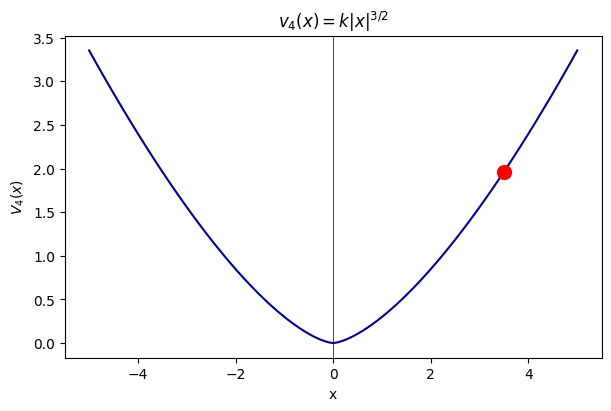

In [12]:
# Grafici Potenziali separati

figv1, ax= plt.subplots(1,1, figsize=(6,4), layout='constrained')
ax.plot(xx, V1(xx,k), color='darkblue')
ax.axvline(color='k', linewidth=0.5)
ax.plot(4., V1(4.,k), 'o', markersize=10, color='r')
ax.set_xlabel('x', fontsize=10)
ax.set_ylabel(r'$V_1(x)$', fontsize=10)
ax.set_title(r"$v_1(x)=kx^2$", fontsize=12)

figv2, ax= plt.subplots(1,1, figsize=(6,4), layout='constrained')
ax.plot(xx, V2(xx,k), color='darkblue')
ax.axvline(color='k', linewidth=0.5)
ax.plot(4., V2(4.,k), 'o', markersize=10, color='r')
ax.set_xlabel('x', fontsize=10)
ax.set_ylabel(r'$V_2(x)$', fontsize=10)
ax.set_title(r"$v_2(x)=kx^4$", fontsize=12)

figv3, ax= plt.subplots(1,1, figsize=(6,4), layout='constrained')
ax.plot(xx, V3(xx,k), color='darkblue')
ax.axvline(color='k', linewidth=0.5)
ax.plot(4.2, V3(4.2,k), 'o', markersize=10, color='r')
ax.set_xlabel('x', fontsize=10)
ax.set_ylabel(r'$V_3(x)$', fontsize=10)
ax.set_title(r"$v_3(x)=kx^6$", fontsize=12)

figv4, ax= plt.subplots(1,1, figsize=(6,4), layout='constrained')
ax.plot(xx, V4(xx,k), color='darkblue')
ax.axvline(color='k', linewidth=0.5)
ax.plot(3.5, V4(3.5,k), 'o', markersize=10, color='r')
ax.set_xlabel('x', fontsize=10)
ax.set_ylabel(r'$V_4(x)$', fontsize=10)
ax.set_title(r"$v_4(x)=k|x|^{3/2}$", fontsize=12)

In [13]:
#Periodo al variare di x0
p1=T(V1,mass, xx)
p2=T(V2,mass, xx)
p3=T(V3,mass, xx)
p4=T(V4,mass, xx)
p_osc=np.array([p1,p2,p3,p4])
print(p_osc)

[[ 0.          3.93392697  5.3427548   6.2238976   6.78266921  7.21956967
   7.52889041  7.80288585  8.00411837  8.19740083  8.34063434  8.48701245
   8.59499594  8.7112532   8.79597807  8.89151616  8.95997092  9.04052201
   9.09708619  9.16637199  9.21394556  9.27450281  9.31509091  9.36871697
   9.40375528  9.45176455  9.48231107  9.52569038  9.55254381  9.59205071
   9.61582653  9.65205377  9.67323474  9.70665383  9.7256245   9.75661594
   9.7736868   9.8025616   9.81798637  9.84500164  9.85898989  9.88436032
   9.8970868   9.92099333  9.93260504  9.95520142  9.96582298  9.98724082
   9.99697865 10.01733141]
 [ 0.         18.55679971 16.61082926 14.25233479 12.2867254  10.80104298
   9.59703161  8.65530969  7.86216195  7.21942929  6.6602082   6.1949088
   5.77985271  5.42768744  5.10742001  4.83163074  4.57693876  4.35508899
   4.14763087  3.96527708  3.79296883  3.64040031  3.49496006  3.36540966
   3.24097204  3.12958007  3.02187461  2.9250611   2.83090438  2.74597376
   2.6629438

Text(0.5, 1.0, 'Periodi di oscillazione $V_4$')

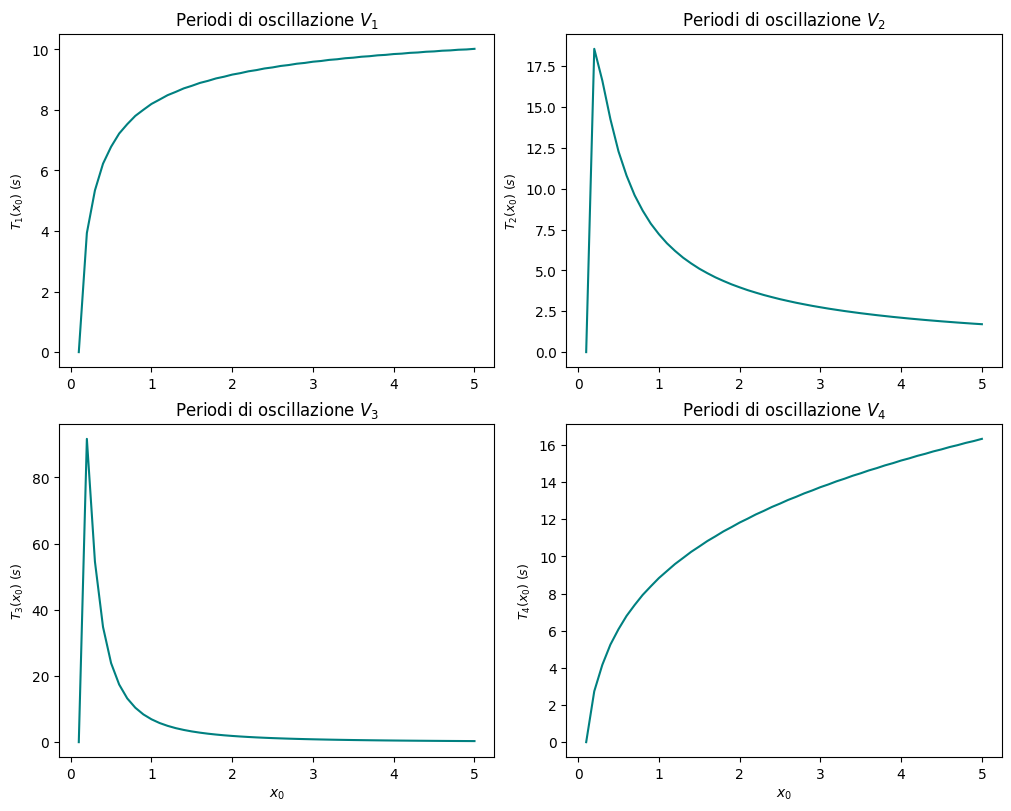

In [14]:
#Grafici Periodi-x0
x_p=np.array([x for x in xx if x>=0])

fig, (ax1,ax2) = plt.subplots(2,2, figsize=(10,8), layout='constrained')
ax1[0].plot(x_p, p1, color='teal')
ax1[0].set_ylabel(r'$T_1(x_0) \; (s)$', fontsize=9)
ax1[0].set_title(r"Periodi di oscillazione $V_1$", fontsize=12)

ax2[0].plot(x_p, p3, color='teal')
ax2[0].set_xlabel(r'$x_0$', fontsize=10)
ax2[0].set_ylabel(r'$T_3(x_0) \; (s)$', fontsize=9)
ax2[0].set_title(r"Periodi di oscillazione $V_3$", fontsize=12)

ax1[1].plot(x_p, p2, color='teal')
ax1[1].set_ylabel(r'$T_2(x_0) \; (s)$', fontsize=9)
ax1[1].set_title(r"Periodi di oscillazione $V_2$", fontsize=12)

ax2[1].plot(x_p, p4, color='teal')
ax2[1].set_xlabel(r'$x_0$', fontsize=10)
ax2[1].set_ylabel(r'$T_4(x_0) \; (s)$', fontsize=9)
ax2[1].set_title(r"Periodi di oscillazione $V_4$", fontsize=12)

Text(0.5, 1.0, 'Periodi di oscillazione $V_4$')

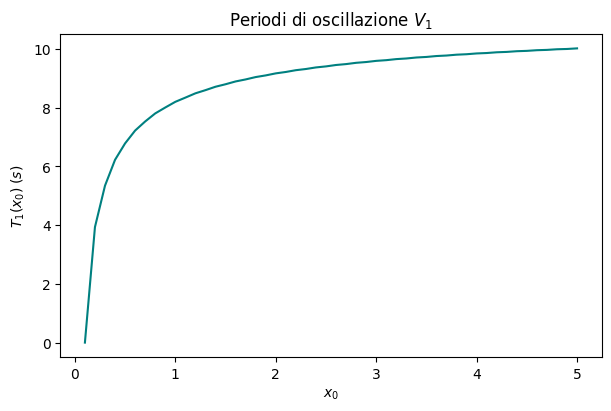

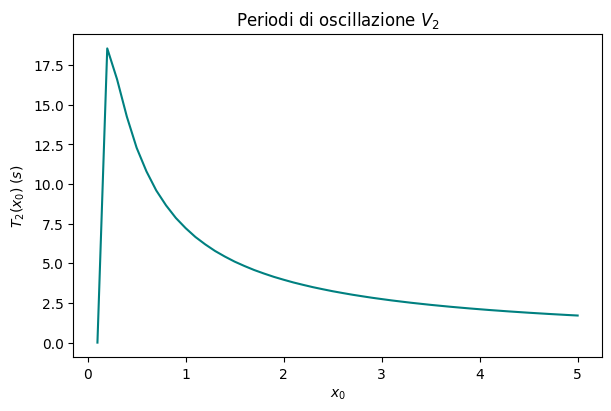

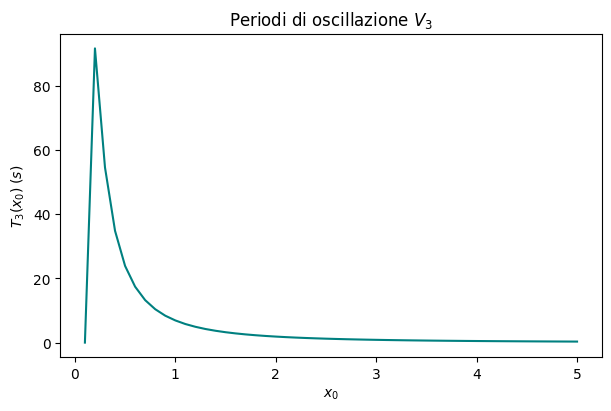

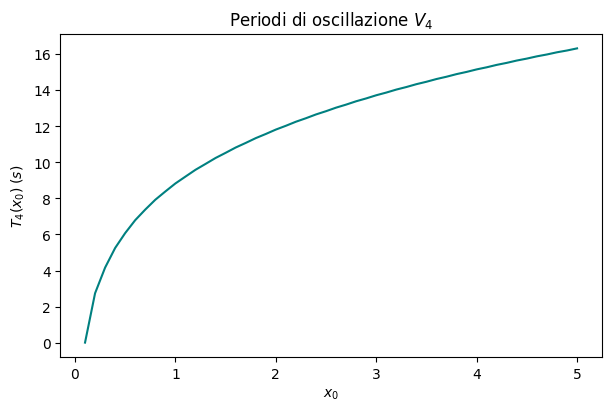

In [15]:
#Grafici Periodi separati
figp1, ax=plt.subplots(1,1, figsize=(6,4), layout='constrained')
ax.plot(x_p, p1, color='teal')
ax.set_xlabel(r'$x_0$', fontsize=10)
ax.set_ylabel(r'$T_1(x_0) \; (s)$', fontsize=10)
ax.set_title(r"Periodi di oscillazione $V_1$", fontsize=12)

figp2, ax=plt.subplots(1,1, figsize=(6,4), layout='constrained')
ax.plot(x_p, p2, color='teal')
ax.set_xlabel(r'$x_0$', fontsize=10)
ax.set_ylabel(r'$T_2(x_0) \; (s)$', fontsize=10)
ax.set_title(r"Periodi di oscillazione $V_2$", fontsize=12)

figp3, ax=plt.subplots(1,1, figsize=(6,4), layout='constrained')
ax.plot(x_p, p3, color='teal')
ax.set_xlabel(r'$x_0$', fontsize=10)
ax.set_ylabel(r'$T_3(x_0) \; (s)$', fontsize=10)
ax.set_title(r"Periodi di oscillazione $V_3$", fontsize=12)


figp4, ax=plt.subplots(1,1, figsize=(6,4), layout='constrained')
ax.plot(x_p, p4, color='teal')
ax.set_xlabel(r'$x_0$', fontsize=10)
ax.set_ylabel(r'$T_4(x_0) \; (s)$', fontsize=10)
ax.set_title(r"Periodi di oscillazione $V_4$", fontsize=12)

### Gestione dello scipt da riga di comando

In [ ]:
def parse_arguments():
    parser = argparse.ArgumentParser(description= 'Periodi di oscillazione di potenziali al variare del punto iniziale')
    group=parser.add_mutually_exclusive_group()
    parser.add_argument('-set','--set_potential', action='store_true', help='set mass and potential constant' )
    parser.add_argument('-v1','--v1_potential', action='store_true', help='show V1 potential graph')
    parser.add_argument('-v2','--v2_potential', action='store_true', help='show V2 potential graphs' )
    parser.add_argument('-v3','--v3_potential', action='store_true', help='show V3 potential graph' )
    parser.add_argument('-v4','--v4_potential', action='store_true', help='show V4 potential graph')
    parser.add_argument('-allv','--all_potentials', action='store_true', help='show potentials graphs')
    parser.add_argument('-p1','--v1_periods', action='store_true', help='show V1 periods graph')
    parser.add_argument('-p2','--v2_periods', action='store_true', help='show V2 periods graph')
    parser.add_argument('-p3','--v3_periods', action='store_true', help='show V3 periods graph')
    parser.add_argument('-p4','--v4_periods', action='store_true', help='show V4 periods graph')
    parser.add_argument('-allp','--all_periods', action='store_true', help='show periods graph')

    return parser.parse_args()

def main():
    control=False
    args=parse_arguments()
    if args.set_potential == True:
        control=True
        mass,k=set_V(mass=2, k=2)  
        print('massa: {:} , k: {:}'.format(mass, k))
    if args.v1_potential == True:
        if control==False: args.set_potential
        else:
            print("$ V_1(x) = {:} x^2$".format(k))
            v1_plot()
    if args.v2_potential == True:
        if control==False: args.set_potential
        else:
            print("$ V_2(x) ={:} x^4$".format(k))
            v2_plot()
    if args.v3_potential == True:
        if control==False: args.set_potential
        else:
            print("$ V_3(x) = {:} x^6$".format(k))
            v3_plot()
    if args.v4_potential == True:
        if control==False: args.set_potential
        else:
            print("$ V_1(x) = {:} |x|^{3/2}$".format(k))
            v4_plot()
    if args.all_potential == True:
        if control==False: args.set_potential
        else:
            allv_plot()
    if args.v1_periods == True:
        if control==False: args.set_potential
        else:
            p1_plot()
    if args.v2_periods == True:
        if control==False: args.set_potential
        else:
            p2_plot()
    if args.v3_periods == True:
        if control==False: args.set_potential
        else:
            p3_plot()
    if args.v4_periods == True:
        if control==False: args.set_potential
        else:
            p4_plot()
    if args.all_periods == True:
        if control==False: args.set_potential
        else:
            allp_plot()     

if __name__ == "__main__":
    main()